In [4]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH="./data/csv"
LOG_PATH="./data/log"


In [26]:
df = pd.read_csv(f"{CSV_PATH}/trace_batch1.csv", names=['Job','Start','End','Specs'], header=None)
df['Round'] = df['Job'].apply(lambda x: int(x.split('-')[1].split('round')[-1]))
df['Job_ID'] = df['Job'].apply(lambda x: int(x.split('-')[2].split('job')[-1]))
df['Model Name'] = df['Job'].apply(lambda x: '_'.join(x.split('-')[3:]))
df['P/S'] = df['Specs'].apply(lambda x: 'S' if 'execlusive' in x else 'P')
df.tail()

,Job,Start,End,Specs,Round,Job_ID,Model Name,P/S
139,ops-round35-job3-eleutherai-pythia-1b,2026-08-27T05:57:23Z,2026-08-27T06:14:29Z,round_35_job_3_eleutherai-pythia-1b,35,3,eleutherai_pythia_1b,P
140,ops-round1-job0-bigscience-bloom-1b1,2026-08-27T10:36:50Z,2026-08-27T10:45:18Z,execution_1_bigscience-bloom-1b1_execlusive,1,0,bigscience_bloom_1b1,S
141,ops-round2-job0-eleutherai-pythia-160m,2026-08-27T08:04:17Z,2026-08-27T08:07:29Z,execution_2_eleutherai-pythia-160m_execlusive,2,0,eleutherai_pythia_160m,S
142,ops-round3-job0-qwen-qwen2-5-0-5b,2026-08-27T08:07:31Z,2026-08-27T08:13:16Z,execution_3_qwen-qwen2-5-0-5b_execlusive,3,0,qwen_qwen2_5_0_5b,S
143,ops-round4-job0-eleutherai-pythia-1b,2026-08-27T08:13:17Z,2026-08-27T08:21:12Z,execution_4_eleutherai-pythia-1b_execlusive,4,0,eleutherai_pythia_1b,S


In [27]:
# Extract measured steps, total wall (s), avg step (ms), tokens/sec (ws), peak mem (GB,r0), avg loss, final loss, empty batches
from pathlib import Path

from data.parse_logs import extract_job_metrics


log_files = sorted(Path(LOG_PATH).glob("*.log"))
log_dataframes = []

for log_file in log_files:
    job_metrics = extract_job_metrics(log_file)
    if job_metrics:
        log_dataframes.append(pd.DataFrame(job_metrics))

metrics_df = (
    pd.concat(log_dataframes, ignore_index=True)
    if log_dataframes
    else pd.DataFrame()
)


metrics_df['Round'] = metrics_df['job'].apply(lambda x: int(x.split('-')[1].split('round')[-1]))
metrics_df['Job_ID'] = metrics_df['job'].apply(lambda x: int(x.split('-')[2].split('job')[-1]))
metrics_df['Model Name'] = metrics_df['job'].apply(lambda x: '_'.join(x.split('-')[3:-1]) if 'execlusive' in x else '_'.join(x.split('-')[3:]))
metrics_df['P/S'] = metrics_df['job'].apply(lambda x: 'S' if 'execlusive' in x else 'P')
metrics_df.head()

,job,measured_steps,total_wall_s,avg_step_ms,tokens_per_sec_ws,peak_mem_gb_r0,avg_loss,final_loss,empty_batches,Round,Job_ID,Model Name,P/S
0,ops-round1-job0-bigscience-bloom-1b1-execlusive,40.0,352.2,6899.2,148.4,4.85,141.7703,87.6960,0.0,1,0,bigscience_bloom_1b1,S
1,ops-round2-job0-eleutherai-pythia-160m-execlusive,40.0,69.5,1325.9,772.3,0.85,9.8191,9.3685,0.0,2,0,eleutherai_pythia_160m,S
2,ops-round3-job0-qwen-qwen2-5-0-5b-execlusive,40.0,184.8,3593.3,285.0,2.53,260.7591,95.9310,0.0,3,0,qwen_qwen2_5_0_5b,S
3,ops-round4-job0-eleutherai-pythia-1b-execlusive,40.0,316.3,6117.5,167.4,1.57,8.6061,8.3009,0.0,4,0,eleutherai_pythia_1b,S
4,ops-round10-job0-bigscience-bloom-1b1,40.0,400.9,7920.3,129.3,4.85,144.8420,90.1973,0.0,10,0,bigscience_bloom_1b1,P


In [34]:
merge_keys = ['Round', 'Job_ID', 'Model Name', 'P/S']
df_all = df.merge(metrics_df, on=merge_keys, how='left')
df_all.drop(labels='job', axis=1, inplace=True)
df_all.dropna(inplace=True)
df_all.head()

,Job,Start,End,Specs,Round,Job_ID,Model Name,P/S,measured_steps,total_wall_s,avg_step_ms,tokens_per_sec_ws,peak_mem_gb_r0,avg_loss,final_loss,empty_batches
0,ops-round1-job0-bigscience-bloom-1b1,2026-08-27T00:15:34Z,2026-08-27T00:25:04Z,round_1_job_0_bigscience-bloom-1b1,1,0,bigscience_bloom_1b1,P,40.0,404.0,7979.2,128.3,4.85,140.7208,88.2215,0.0
1,ops-round1-job1-bigscience-bloom-1b1,2026-08-27T00:15:35Z,2026-08-27T00:25:03Z,round_1_job_1_bigscience-bloom-1b1,1,1,bigscience_bloom_1b1,P,40.0,406.3,7985.8,128.2,4.85,141.8836,88.0102,0.0
2,ops-round1-job2-bigscience-bloom-1b1,2026-08-27T00:15:35Z,2026-08-27T00:25:07Z,round_1_job_2_bigscience-bloom-1b1,1,2,bigscience_bloom_1b1,P,40.0,404.3,7970.3,128.5,4.85,142.2282,86.4090,0.0
4,ops-round2-job0-bigscience-bloom-1b1,2026-08-27T00:33:32Z,2026-08-27T00:42:58Z,round_2_job_0_bigscience-bloom-1b1,2,0,bigscience_bloom_1b1,P,40.0,402.8,8009.0,127.9,4.85,139.4502,86.9068,0.0
5,ops-round2-job1-bigscience-bloom-1b1,2026-08-27T00:33:32Z,2026-08-27T00:42:52Z,round_2_job_1_bigscience-bloom-1b1,2,1,bigscience_bloom_1b1,P,40.0,397.3,7949.5,128.8,4.85,141.9807,91.6141,0.0


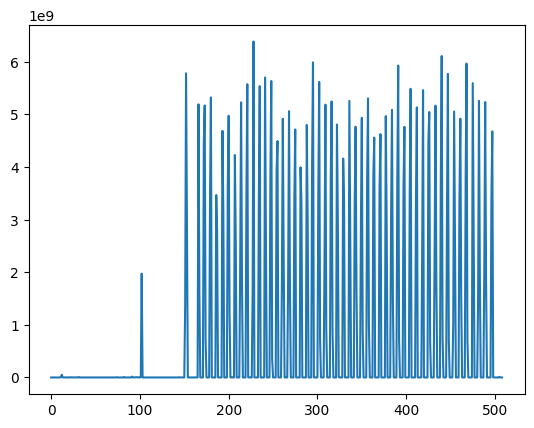

In [ ]:
def get_pcie_demand(df: pd.DataFrame, model_name: str):
    start_time = df.loc[(df['Model Name'] == model_name) & (df['P/S'] == 'S'), 'Start'].item()
    end_time = df.loc[(df['Model Name'] == model_name) & (df['P/S'] == 'S'), 'End'].item()
    df_metrics = pd.read_csv(f"{CSV_PATH}/results_seq.csv")
    values = df_metrics.loc[(df_metrics['timestamp'] >= start_time) & (df_metrics['timestamp'] <= end_time) & (df_metrics["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES"), "value"].to_numpy()
    return values


values = get_pcie_demand(df_all, "bigscience_bloom_1b1")


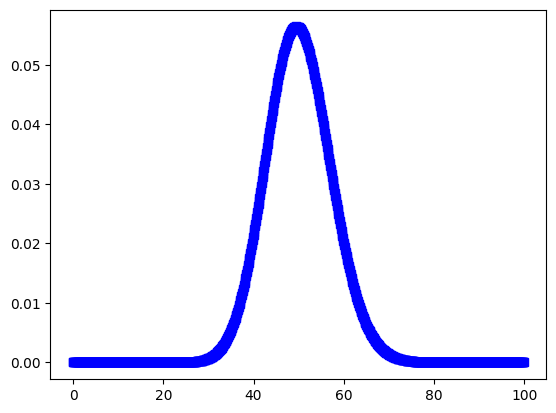

In [7]:
# Source - https://stackoverflow.com/a/51243463
# Posted by bobrobbob, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-03, License - CC BY-SA 4.0

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

t = np.arange(0, 100, 0.1)
arrival_rate = 50
d = np.exp(-arrival_rate)*np.power(arrival_rate, t)/factorial(t)

plt.plot(t, d, 'bs')
plt.show()
